# Instructions on using this Calculator

## Introduction

This Jupyter Notebook can be used to calculate the accuracy of your Model Output. It works as follows. Please ensure the following are loaded into your environment before running this notebook: 

1) All 5 clipped CDL tif images, named 2019_cdl_clipped.tif, 2020_cdl_clipped.tif, 2021_cdl_clipped.tif, 2022_cdl_clipped.tif and 2023_cdl_clipped.tif
2) The vector image output from your model, named model_output.tif

In addition, please make sure your notebook has at least 24 cores at 8GB each, otherwise some of these accuracy calculations will take a very long time.

This code has 4 steps to it. Steps 1-3 on

## Step 1 - CDL Image Labeling

This section of code will process each CDL filed into a data frame. The data frame will contain the x/y coordinate for each pixel, the pixel's grayscale value, crop type (based on a crop mapping dictionary) and assigned field group (based on groupings of same-color pixels). A majority filter is applied to the dataframe, which is used to remove noise from an image or data. It replaces each pixel's value with the majority of the pixel values in its neighborhood (3x3 square block in this case) of all other pixels in the neighborhood are a uniform color.

Note - You only need to run this step one time in order to prep your CDL dataframes for step 2.

In [1]:
import rasterio
import numpy as np
import pandas as pd
from rasterio.windows import Window
import matplotlib.pyplot as plt
import cv2
from skimage.measure import label
from skimage.transform import resize
from PIL import Image
from scipy.ndimage import generic_filter

In [2]:
# Load Reference CDL Images
reference_tif_2019 = "2019cdl_matched2sentinel.tif"
reference_tif_2020 = "2020_cdl_clipped.tif"
reference_tif_2021 = "2021_cdl_clipped.tif"
reference_tif_2022 = "2022_cdl_clipped.tif"
reference_tif_2023 = "2023_cdl_clipped.tif"

In [4]:
#3, 25, 56, 57, 76,219, 221, 246

In [3]:
#NEED TO UPDATE SO THAT ALL GRAYSCALE VALUES ARE INCLUDED
# Define crop mapping (grayscale values to crop labels)
CROP_TYPE_MAP = {
    0: "Out of Shapefile Bounds",
    1: "Corn", 
    4: "Sorghum", 
    5: "Soybeans", 
    6: "Sunflower", 
    12: "Sweet Corn", 
    13: "Pop or Orn Corn", 
    14: "Mint", 
    21: "Barley", 
    23: "Spring Wheat", 
    24: "Winter Wheat", 
    26: "Dbl Crop WinWht/Soybeans", 
    27: "Rye",
    28: "Oats",
    29: "Millet",
    30: "Speltz",
    31: "Canola",
    36: "Alfalfa",
    37: "Other Hay/Non Alfalfa",
    39: "Buckwheat",
    41: "Sugarbeets",
    42: "Dry Beans",
    43: "Potatoes",
    44: "Other Crops",
    47: "Misc Vegs & Fruits",
    48: "Watermelons",
    49: "Onions",
    50: "Cucumbers",
    53: "Peas",
    54: "Tomatoes",
    58: "Clover/Wildflowers",
    59: "Sod/Grass Seed",
    60: "Switchgrass",
    61: "Fallow/Idle Cropland",
    66: "Cherries",
    67: "Peaches",
    68: "Apples",
    69: "Grapes",
    70: "Christmas Trees",
    71: "Other Tree Crops",
    77: "Pears",
    92: "Aquaculture",
    111: "Open Water",
    121: "Developed/Open Space",
    122: "Developed/Low Intensity",
    123: "Developed/Med Intensity ",
    124: "Developed/High Intensity",
    131: "Barren",
    141: "Deciduous Forest",
    142: "Evergreen Forest",
    143: "Mixed Forest",
    152: "Shrubland",
    176: "Grassland/Pasture",
    190: "Woody Wetlands",
    195: "Herbaceous Wetlands",
    205: "Triticale",
    206: "Carrots",
    207: "Asparagus",
    209: "Cantaloupes",
    216: "Peppers",
    220: "Plums",
    222: "Squash",
    225: "Dbl Crop WinWht/Corn",
    228: "Dbl Crop Triticale/Corn",
    229: "Pumpkins",
    236: "Dbl Crop WinWht/Sorghum",
    240: "Dbl Crop Soybeans/Oats",
    242: "Blueberries",
    243: "Cabbage",
    245: "Celery",
    247: "Turnips"
}

In [4]:
#Create Majority Filter that will be used to filter out noise
def conditional_majority_filter(image, size=3):
    """Applies a majority filter only if the center pixel is the only outlier.
    
    Args:
        image (numpy array): The input image.
        size (int): The size of the filtering window (default is 3x3).
        
    Returns:
        numpy array: The filtered image.
    """
    def majority_if_outlier(values):
        center_pixel = values[len(values) // 2]  # Center pixel in the window
        surrounding_pixels = np.delete(values, len(values) // 2)  # Exclude center pixel
        
        # Check if all surrounding pixels are the same
        if np.all(surrounding_pixels == surrounding_pixels[0]) and center_pixel != surrounding_pixels[0]:
            return surrounding_pixels[0]  # Replace with majority (surrounding value)
        else:
            return center_pixel  # Keep original value

    return generic_filter(image, majority_if_outlier, size=(size, size))

In [5]:
#Uses the CROP_TYPE_MAP to apply crop labels to each pixel based on their grayscale value

def label_crops (reference_tif):
# Open the TIFF image
    with rasterio.open(reference_tif) as src:
        # Read the image data (first band)
        band = src.read(1)  # Read the first band (single-band image)

        # Get the image dimensions
        height, width = band.shape

    # Generate x and y coordinate arrays
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten the arrays and create a DataFrame
    df = pd.DataFrame({
        'x': x_coords.flatten(),
        'y': y_coords.flatten(),
        'grayscale_value': band.flatten()
    })
    
    # Function to map grayscale values to crop types
    def map_crop(grayscale_value):
        return CROP_TYPE_MAP.get(grayscale_value, "Unknown")  # Default to "Unknown" if not found

    # Apply the mapping function to create the 'crop_type' column
    df['crop_type'] = df['grayscale_value'].apply(map_crop)

    # Display the first few rows of the DataFrame
    return df

In [6]:
#Function to group pixels together based on color and assign field labels (with majority filter). Adds field_id column onto existing dataframe
def label_fields_with_filter(df: pd.DataFrame, reference_tif):
    # Open the TIFF file
    with rasterio.open(reference_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    #Apply a majority filter to remove noise & prevent small pixel errors (removing this line keeps noise)
    ref_image = conditional_majority_filter(ref_image, size=3)    

    height, width = ref_image.shape
    
    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category
        labeled_regions = label(mask)  

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

In [7]:
#Process CDL tifs with filter
field_label_df_2019_with_filter, field_labels_2019_with_filter = label_fields_with_filter((label_crops(reference_tif_2019)), reference_tif_2019)
#field_label_df_2020_with_filter, field_labels_2020_with_filter = label_fields_with_filter((label_crops(reference_tif_2020)), reference_tif_2020)
#field_label_df_2021_with_filter, field_labels_2021_with_filter = label_fields_with_filter((label_crops(reference_tif_2021)), reference_tif_2021)
#field_label_df_2022_with_filter, field_labels_2022_with_filter = label_fields_with_filter((label_crops(reference_tif_2022)), reference_tif_2022)
#field_label_df_2023_with_filter, field_labels_2023_with_filter = label_fields_with_filter((label_crops(reference_tif_2023)), reference_tif_2023)

In [17]:
######## EVERYTHING AFTER THIS POINT IN STEP 1 IS USED TO PERFORM RESEARCH OR CREATE VISUALIZATIONS FOR THE REPORT. YOU CAN SKIP TO STEP 2 ######## 

In [3]:
#Saves file references in list
tif_files = [
    reference_tif_2019,
    reference_tif_2020,
    reference_tif_2021,
    reference_tif_2022,
    reference_tif_2023
]

In [118]:
#The following grayscsale values exist in the tif images, but do not have a crop label in the metadata: 3, 25, 56, 57, 76,219, 221, 246

,x,y,grayscale_value,crop_type,field_id
2463226,480,1027,56,Unknown,72816


In [119]:
#Code look at how many differet crop labels exist in 1 field
print("Unique field IDs assigned:", np.unique(field_labels_2019_with_filter))
print(field_label_df_2019_with_filter.groupby("field_id")["crop_type"].nunique().sort_values(ascending=False))

Unique field IDs assigned: [     0      2      3 ... 170402 170403 170404]
field_id
141091    7
157027    6
75490     6
155194    6
50511     6
         ..
57336     1
57337     1
57338     1
57339     1
170404    1
Name: crop_type, Length: 170355, dtype: int64


In [37]:
#Print number of unique fields for a year
num_unique_fields = field_label_df_2019_with_filter["field_id"].nunique()
print(f"Number of unique fields: {num_unique_fields}")

Number of unique fields: 170355


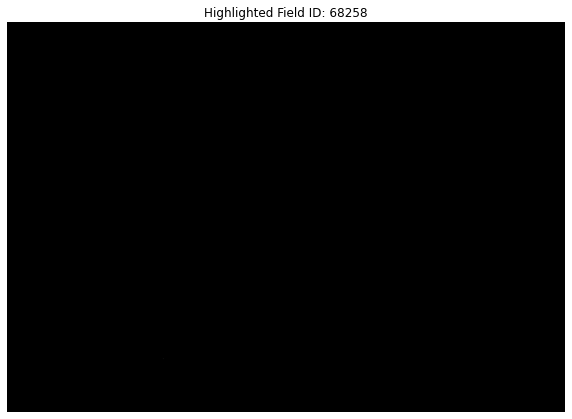

In [38]:
# Show visualization of a specific field

# Select the field ID you want to highlight
target_field_id = 68258  # Change this to the field ID you want to highlight

# Create a binary mask: White (255) for the target field, Black (0) for others
highlight_mask = np.zeros_like(field_labels_2019_with_filter, dtype=np.uint8)
highlight_mask[field_labels_2019_with_filter == target_field_id] = 255  # Set the target field to white

# Display the mask
plt.figure(figsize=(10, 10))
plt.imshow(highlight_mask, cmap='gray')  # Black & White representation
plt.title(f"Highlighted Field ID: {target_field_id}")
plt.axis('off')  # Hide axes for a clean image
plt.show()

Displaying mask for grayscale value: 0


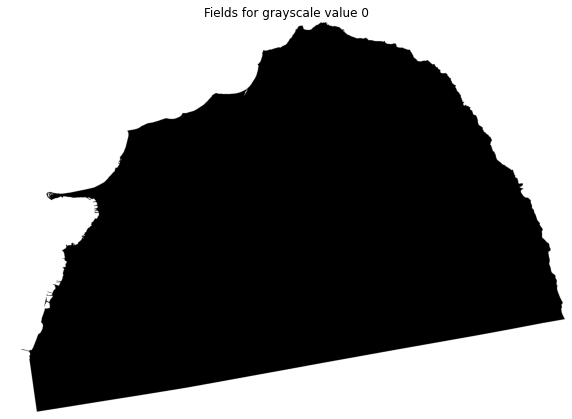

In [99]:
#Show all fields for a specific grayscale value

# Specify the grayscale value you want to display (change it to the value you're interested in)
with rasterio.open(reference_tif_2021) as src:
    ref_image2019 = src.read(1)

test_value = 0  # Replace with your desired grayscale value
print(f"Displaying mask for grayscale value: {test_value}")

# Create a binary mask where all pixels matching the test_value are white (1), others are black (0)
test_mask = (ref_image2019 == test_value)

# Display the mask using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(test_mask, cmap="gray")
plt.title(f"Fields for grayscale value {test_value}")
plt.axis("off")  # Optional: Hide axis for a cleaner map
plt.show()

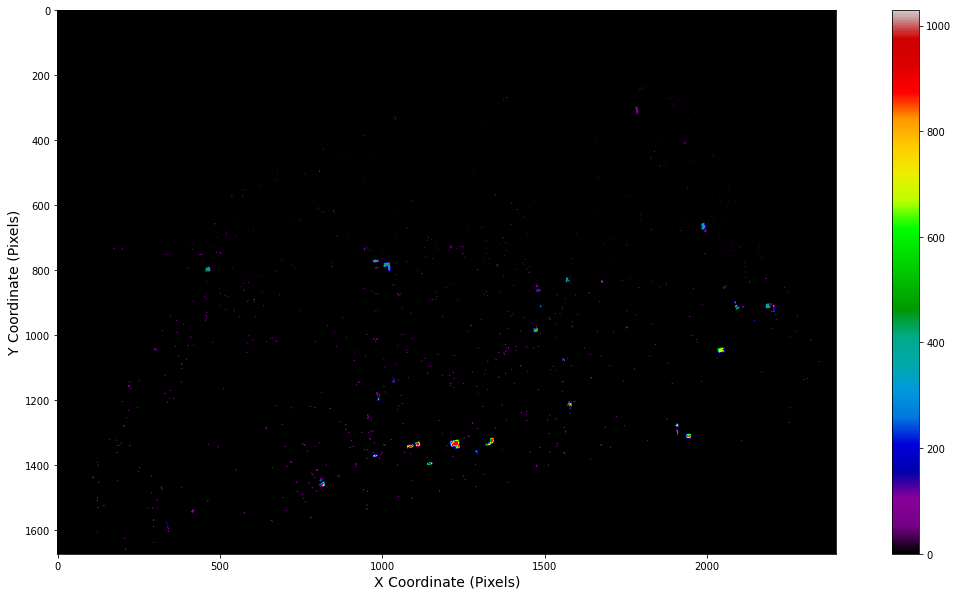

In [33]:
#Show all fields for a specific grayscale value with colored field labels
labeled_test_mask = label(test_mask)
# Display the mask using matplotlib
plt.figure(figsize=(20, 10))
plt.imshow(labeled_test_mask, cmap="nipy_spectral")  # Use a colorful colormap
#plt.title(f"Fields for grayscale value {test_value}")
plt.colorbar()
plt.xlabel("X Coordinate (Pixels)", fontsize=14)
plt.ylabel("Y Coordinate (Pixels)", fontsize=14)
plt.show()

In [40]:
# Get the top 10 field_ids with the most records
top_10_field_ids = field_labels_2019["field_id"].value_counts().head(10)

print("Top 10 field_ids with the most records:")
print(top_10_field_ids)

Top 10 field_ids with the most records:
0       1608690
2552       7101
2288       5847
518        4565
6940       4507
5425       4351
956        3849
689        3844
4461       3713
2406       3573
Name: field_id, dtype: int64


In [8]:
#This cell is run to print all unique grayscale values, so we can make sure our crop dictionary is inclusive of everytihng
# Set to store all unique grayscale values across files
all_unique_values = set()

# Loop through the specified TIFF files and prints grayscale values
for tif_path in tif_files:
    with rasterio.open(tif_path) as src:
        band = src.read(1)  # Read the single-band image
        unique_values = np.unique(band)  # Get unique values in this image
        all_unique_values.update(unique_values)  # Add to global set
    
    print(f"Unique grayscale values in {tif_path}: {unique_values}")

Unique grayscale values in 2019_cdl_clipped.tif: [  0   1   4   5  12  13  14  21  24  25  27  28  30  36  37  41  42  43
  44  49  50  53  54  56  57  58  59  61  66  68  70 111 121 122 123 124
 131 141 142 143 152 176 190 195 205 206 219 222 225 229 243]
Unique grayscale values in 2020_cdl_clipped.tif: [  0   1   3   4   5   6  12  13  14  21  22  24  26  27  28  29  30  36
  37  39  41  42  43  44  47  48  49  50  53  54  56  58  59  60  61  66
  68  70  71  76 111 121 122 123 124 131 141 142 143 152 176 190 195 205
 206 222 225 229 242 243 246]
Unique grayscale values in 2021_cdl_clipped.tif: [  0   1   4   5   6  12  13  14  21  24  26  27  28  29  30  31  36  37
  39  41  42  43  44  47  49  50  53  54  56  57  58  59  61  66  68  69
  70  71  76  77  92 111 121 122 123 124 131 141 142 143 152 176 190 195
 205 206 207 216 219 221 222 225 228 229 242 243 245 246]
Unique grayscale values in 2022_cdl_clipped.tif: [  0   1   4   5   6  12  14  21  23  24  26  27  28  29  30  36  37  

## Step 2 - Model Output Image Processing

This code will define functions that will process a grayscale model output tif into a data frame. The data frame will contain the x/y coordinate for each pixel, the pixel's grayscale value and assigned field group (based on groupings of same-color pixels).

In [8]:
#Define function to process model output
def label_satelite_pixels(model_output_tif):
    with rasterio.open(model_output_tif) as src:
        band = src.read(1).astype(np.uint8)  # Read and convert to uint8 if needed

        # Get original dimensions
        height, width = band.shape

    # Generate x and y coordinate arrays
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten and create DataFrame
    df = pd.DataFrame({
        'x': x_coords.flatten(),
        'y': y_coords.flatten(),
        'grayscale_value': band.flatten()
    })

    return df

In [9]:
#Function to group pixels together based on color and assign field labels (no median filter). Adds field_id column onto existing dataframe
def process_model_output (df: pd.DataFrame, model_output_tif):
    # Open the TIFF file
    with rasterio.open(model_output_tif) as ref_src:
        ref_image = ref_src.read(1)  # Read as grayscale
        ref_image = ref_image.astype(np.uint8)

    height, width = ref_image.shape
    
    # Get unique grayscale values (excluding 0 as background)
    unique_values = np.unique(ref_image)
    filtered_values = unique_values[unique_values > 0]  

    # Prepare empty field ID map
    field_labels = np.zeros_like(ref_image, dtype=np.int32)

    # Initialize field ID counter
    field_counter = 1  

    # Add field_id column to df
    df["field_id"] = 0  

    # Process each grayscale value separately
    for value in filtered_values:
        mask = (ref_image == value)  # Boolean mask for this grayscale value

        # Ensure we only label within this grayscale category
        labeled_regions = label(mask)  

        # Offset labels to ensure uniqueness across grayscale categories
        labeled_regions[labeled_regions > 0] += field_counter  

        # Ensure labels are only updated within this mask
        field_labels[mask] = labeled_regions[mask]

        # Get row and column indices where mask is True
        rows, cols = np.where(mask)

        # Extract the correct field IDs
        field_ids = labeled_regions[rows, cols]

        # Create a DataFrame mapping (y, x) to field_id
        field_update_df = pd.DataFrame({
            "y": rows,
            "x": cols,
            "field_id": field_ids
        })

        # Merge efficiently without overwriting fields incorrectly
        df = df.merge(field_update_df, on=["y", "x"], how="left", suffixes=("", "_new"))
        df["field_id"] = df["field_id_new"].fillna(df["field_id"]).astype(int)
        df.drop(columns=["field_id_new"], inplace=True)

        # Ensure next field ID does not overlap
        field_counter = field_labels.max() + 1  

    return df, field_labels

## Step 3 - Create Accuracy Calculators

This code will create the field noise and pixel-level accuracy calculators. 

In [10]:
#this creates an array of non-crop grayscale values that we want to exclude from the calculation
exclude_grayscale_values = [0, 3, 25, 56, 57, 61, 76, 92, 111, 121, 123, 124, 131, 141, 142, 143, 152, 176, 190, 195, 219, 221, 246]

In [11]:
def compute_field_noise(df_model_output, df_truth, exclude_grayscale_values, bin_size=10): 
    # Print number of records in each DataFrame
    print(f"Records in df_model_output: {len(df_model_output)}")
    print(f"Records in df_truth: {len(df_truth)}")

    # Merge both dataframes on pixel coordinates ("x", "y")
    df_merged = df_model_output.merge(df_truth, on=["x", "y"], suffixes=("_labeled", "_truth"))

    # Determine the majority truth field per labeled field
    majority_truth = df_merged.groupby("field_id_labeled")["field_id_truth"].agg(lambda x: x.value_counts().idxmax()).reset_index()
    majority_truth.rename(columns={"field_id_truth": "majority_truth"}, inplace=True)

    # Merge majority field back into df_merged
    df_merged = df_merged.merge(majority_truth, on="field_id_labeled")

    # Find the grayscale value associated with each majority_truth field
    field_grayscale_values = df_truth.groupby("field_id")["grayscale_value"].first().reset_index()
    df_merged = df_merged.merge(field_grayscale_values, left_on="majority_truth", right_on="field_id", suffixes=("", "_gray"))

    # Exclude fields where the majority corresponds to a grayscale value in the exclusion list
    excluded_fields_by_grayscale = df_merged[df_merged["grayscale_value"].isin(exclude_grayscale_values)]["field_id_labeled"].unique()

    # Count excluded fields due to majority grayscale value in exclusion list
    num_excluded_fields_by_grayscale = len(excluded_fields_by_grayscale)

    # Calculate field sizes (pixel count per field)
    field_sizes = df_model_output.groupby("field_id").size().reset_index(name="field_size")

    # Find 1-pixel fields
    one_pixel_fields = field_sizes[field_sizes["field_size"] == 1]["field_id"].unique()

    # Count excluded 1-pixel fields
    num_excluded_one_pixel_fields = len(one_pixel_fields)

    # Exclude both 1-pixel fields and those from grayscale exclusion
    excluded_fields = set(excluded_fields_by_grayscale) | set(one_pixel_fields)
    df_merged = df_merged[~df_merged["field_id_labeled"].isin(excluded_fields)]

    # Compute noise: pixels that do not match the majority field_id_truth
    df_merged["is_noise"] = df_merged["field_id_truth"] != df_merged["majority_truth"]

    # Compute noise score (percentage of noisy pixels per field)
    noise_scores = df_merged.groupby("field_id_labeled")["is_noise"].mean().reset_index()
    noise_scores.rename(columns={"field_id_labeled": "field_id", "is_noise": "noise_score"}, inplace=True)

    # Merge noise scores with field sizes (after filtering)
    df_noise = noise_scores.merge(field_sizes, on="field_id")

    # Assign bin labels (e.g., "1-10", "11-20", etc.)
    df_noise["field_size_bin"] = (df_noise["field_size"] // bin_size) * bin_size
    df_noise["field_size_bin"] = df_noise["field_size_bin"].astype(str) + "-" + (df_noise["field_size_bin"] + bin_size).astype(str)

    # Compute average noise score per bin and count fields in each bin
    df_avg_noise = df_noise.groupby("field_size_bin").agg(
        avg_noise_score=("noise_score", "mean"),
        field_count=("field_id", "count")
    ).reset_index()

    # Rename for clarity
    df_avg_noise.rename(columns={"field_size_bin": "field_size"}, inplace=True)

    # Sort by lower bound of field_size bin
    df_avg_noise["sort_key"] = df_avg_noise["field_size"].str.extract(r"^(\d+)", expand=False).astype(int)
    df_avg_noise = df_avg_noise.sort_values(by="sort_key").drop(columns="sort_key")

    # Print excluded pixel info
    print(f"Excluded {num_excluded_one_pixel_fields} fields with only 1 pixel.")
    print(f"Excluded {num_excluded_fields_by_grayscale} fields due to majority grayscale value being in the excluded list.")
    
    # Calculate total average noise across all fields
    total_avg_noise = df_noise["noise_score"].mean()
    print(f"Total average field noise across all fields: {total_avg_noise:.4f}")

    return df_avg_noise

In [12]:
def compute_pixel_level_accuracy(df_model_output, df_truth, exclude_values):
    # Print number of records in each DataFrame
    print(f"Records in df_model_output: {len(df_model_output)}")
    print(f"Records in df_truth: {len(df_truth)}")
    
    # Rename 'field_id' columns to avoid confusion after merging
    df_model_output = df_model_output.rename(columns={"field_id": "field_id_labeled"})
    df_truth = df_truth.rename(columns={"field_id": "field_id_truth"})

    # Count initial records
    initial_model_records = len(df_model_output)
    initial_truth_records = len(df_truth)

    # Step 1: Filter out excluded grayscale values from df_truth only
    removed_truth_pixels = df_truth[df_truth["grayscale_value"].isin(exclude_values)]
    df_truth = df_truth[~df_truth["grayscale_value"].isin(exclude_values)]

    # Step 2: Identify corresponding (x, y) coordinates
    removed_xy_coords = set(zip(removed_truth_pixels["x"], removed_truth_pixels["y"]))

    # Step 3: Remove the same (x, y) coordinates from df_model_output
    df_model_output = df_model_output[~df_model_output.set_index(["x", "y"]).index.isin(removed_xy_coords)]

    # Count removed records
    removed_pixels_model = initial_model_records - len(df_model_output)
    removed_pixels_truth = initial_truth_records - len(df_truth)

    print(f"Removed {removed_pixels_truth} pixels from df_truth and {removed_pixels_model} corresponding pixels from df_model_output.")

    # Merge dataframes on coordinates ("x", "y") to align model output with truth
    df_merged = df_model_output.merge(df_truth, on=["x", "y"], suffixes=("_labeled", "_truth"))

    # Get expected field sizes using .value_counts() (faster than groupby)
    expected_field_sizes = df_truth["field_id_truth"].value_counts()

    # Map expected field sizes to df_merged
    df_merged["expected_count"] = df_merged["field_id_truth"].map(expected_field_sizes)

    # Count how many expected pixels are in the same model field
    match_counts = df_merged.groupby(["field_id_labeled", "field_id_truth"]).size()

    # Map match counts back to df_merged
    df_merged["match_count"] = df_merged.set_index(["field_id_labeled", "field_id_truth"]).index.map(match_counts)

    # Compute accuracy per pixel
    df_merged["pixel_accuracy"] = (df_merged["match_count"] / df_merged["expected_count"]).astype(np.float32)

    # Compute overall accuracy as the mean accuracy across all pixels
    overall_accuracy = df_merged["pixel_accuracy"].mean()

    print(f"Overall Pixel-Level Accuracy: {overall_accuracy:.2%}")

    return overall_accuracy

## Step 4 - Perform Accuracy Calculation

This section of code performs the accuracy calculation. The model_output and df_truth variables in the cell below should be changed by the user to reference your model output image and associated CDL image that you want to compare it to.

In [27]:
# First, process your model output
model_output = "lin.tif" #Replace monica.tif with your model output tif file
df_truth = field_label_df_2019_with_filter #Replace with cdl year you want to compare to
df_model_output, field_labels = process_model_output((label_satelite_pixels(model_output)), model_output)

Calculator 1 - Field Noise -  For each field in the model output, this calculation will identify how many pixels were expected to be in a different field based on the CDL image. The majority field is considered the "correct" field. For instance, if a field has 10 pixels, where 3 of them belong to the same field per the CDL file, and the other 7 all belong to 7 different fields per the CDL file, then the 3 pixels would be considered the "correct" field and the noise score would be 70%.

A lower avg_noise_score is better (less noise).

Parameters: 
* df_model_output = Processed model output
* df_truth = Processed CDL file for the corresponding year
* bin_size = Groups field sizes together to calculate average noise (defaults to 10)

Monica

In [25]:
compute_field_noise(df_model_output, df_truth, exclude_grayscale_values, bin_size = 100)

Records in df_model_output: 31148516
Records in df_truth: 31148516
Excluded 0 fields with only 1 pixel.
Excluded 67 fields due to majority grayscale value being in the excluded list.
Total average field noise across all fields: 0.2945


,field_size,avg_noise_score,field_count
0,1000-1100,0.266600,35
11,1100-1200,0.211539,37
21,1200-1300,0.263520,37
28,1300-1400,0.205622,33
36,1400-1500,0.194744,36
...,...,...,...
88,35200-35300,0.652540,1
89,35300-35400,0.811166,1
97,42300-42400,0.478982,1
98,42800-42900,0.650763,1


In [26]:
compute_pixel_level_accuracy(df_model_output, df_truth, exclude_grayscale_values)

Records in df_model_output: 31148516
Records in df_truth: 31148516
Removed 14629271 pixels from df_truth and 14629271 corresponding pixels from df_model_output.
Overall Pixel-Level Accuracy: 91.06%


0.9105624

Lin

In [28]:
compute_field_noise(df_model_output, df_truth, exclude_grayscale_values, bin_size = 100)

Records in df_model_output: 31148516
Records in df_truth: 31148516
Excluded 1436 fields with only 1 pixel.
Excluded 2156 fields due to majority grayscale value being in the excluded list.
Total average field noise across all fields: 0.2530


,field_size,avg_noise_score,field_count
0,0-100,0.179745,3272
1,100-200,0.329661,1229
63,200-300,0.354079,406
83,300-400,0.328638,177
99,400-500,0.339928,106
...,...,...,...
85,30600-30700,0.787888,1
87,31400-31500,0.906301,1
88,31700-31800,0.800296,1
90,32600-32700,0.710608,1


In [29]:
compute_pixel_level_accuracy(df_model_output, df_truth, exclude_grayscale_values)

Records in df_model_output: 31148516
Records in df_truth: 31148516
Removed 14629271 pixels from df_truth and 14629271 corresponding pixels from df_model_output.
Overall Pixel-Level Accuracy: 85.48%


0.8548082

In [30]:
unique_field_ids = df_model_output['field_id'].unique()

# Print the unique field IDs
print("Unique field IDs:", unique_field_ids)

Unique field IDs: [   0 9064 9097 ... 6104 6073 6049]


In [17]:
# Count how many pixels of each grayscale value exist
grayscale_counts = df_model_output['grayscale_value'].value_counts()

# Display the counts
print(grayscale_counts)

0    27046569
1     4101947
Name: grayscale_value, dtype: int64


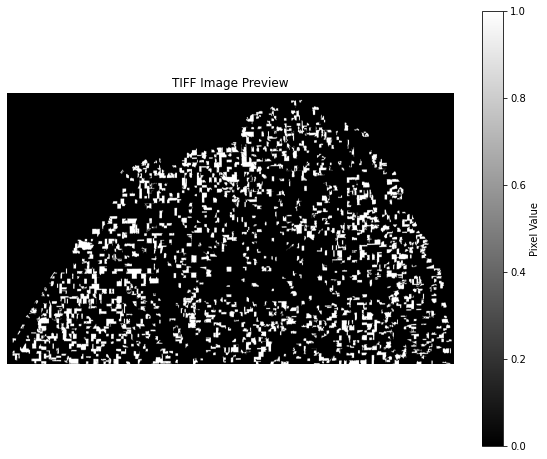

In [18]:
# Path to your TIFF image
tif_path = "monica.tif"

# Open and display the image
with rasterio.open(tif_path) as src:
    band = src.read(1)  # Read the first band

plt.figure(figsize=(10, 8))
plt.imshow(band, cmap="gray")
plt.title("TIFF Image Preview")
plt.colorbar(label="Pixel Value")
plt.axis("off")
plt.show()

In [22]:
test_df = label_crops("lin.tif")

In [23]:
test_df

,x,y,grayscale_value,crop_type
0,0,0,0,Out of Shapefile Bounds
1,1,0,0,Out of Shapefile Bounds
2,2,0,0,Out of Shapefile Bounds
3,3,0,0,Out of Shapefile Bounds
4,4,0,0,Out of Shapefile Bounds
...,...,...,...,...
31148511,7149,4353,0,Out of Shapefile Bounds
31148512,7150,4353,0,Out of Shapefile Bounds
31148513,7151,4353,0,Out of Shapefile Bounds
31148514,7152,4353,0,Out of Shapefile Bounds


In [24]:
# Count how many pixels of each grayscale value exist
grayscale_counts = test_df['grayscale_value'].value_counts()

# Display the counts
print(grayscale_counts)

0      26060221
24        70309
191       70255
169       59233
55        57992
         ...   
115        4687
13         4328
235        4222
136        3802
53         3366
Name: grayscale_value, Length: 256, dtype: int64
